In [6]:
# Cell 1：安装依赖（已安装可跳过）
%pip install -q imageio-ffmpeg numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import subprocess
import numpy as np
import imageio_ffmpeg
import scipy.io.wavfile as wav

AUDIO = 'asset/哈基米_音频.mp4'  
WAV = 'asset/audio.wav'      

ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
subprocess.run([ffmpeg, '-y', '-i', AUDIO, '-vn', '-acodec', 'pcm_s16le',
                '-ar', '16000', '-ac', '1', WAV], capture_output=True)

sr, data = wav.read(WAV)
audio = data.astype(np.float32) / 32768.0  

print('采样率:', sr, 'Hz')
print('采样点数:', len(audio))
print('声道数: 1（已转为单声道）')
print('时长: %.3f 秒' % (len(audio) / sr))
print('幅值范围: [%.4f, %.4f]' % (audio.min(), audio.max()))
print('峰值: %.4f' % np.abs(audio).max())

采样率: 16000 Hz
采样点数: 602976
声道数: 1（已转为单声道）
时长: 37.686 秒
幅值范围: [-0.9362, 0.9436]
峰值: 0.9436


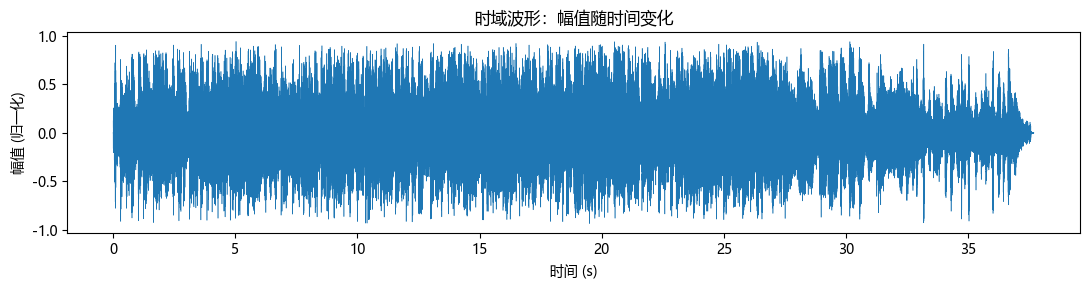

In [3]:
# Cell 3：时域波形可视化
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

t = np.arange(len(audio)) / sr
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t, audio, linewidth=0.4)
ax.set_title('时域波形：幅值随时间变化')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('幅值 (归一化)')
fig.tight_layout()
fig.savefig('asset/waveform.png', dpi=110)
plt.show()

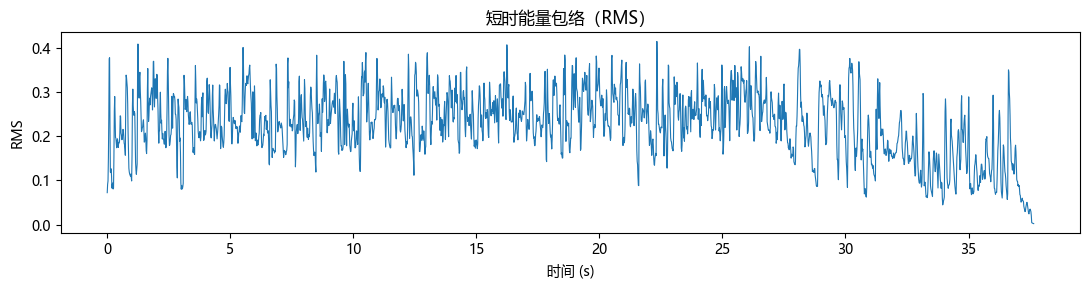

In [4]:
audio = audio - audio.mean()      

def frame_rms(x, frame_len=512, hop=256):
    frames = np.array([x[i:i + frame_len] for i in range(0, len(x) - frame_len, hop)])
    return np.sqrt((frames ** 2).mean(axis=1))

rms = frame_rms(audio)
t_rms = np.arange(len(rms)) * 256 / sr

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t_rms, rms, linewidth=0.8)
ax.set_title('短时能量包络（RMS）')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('RMS')
fig.tight_layout()
fig.savefig('asset/rms.png', dpi=110)
plt.show()

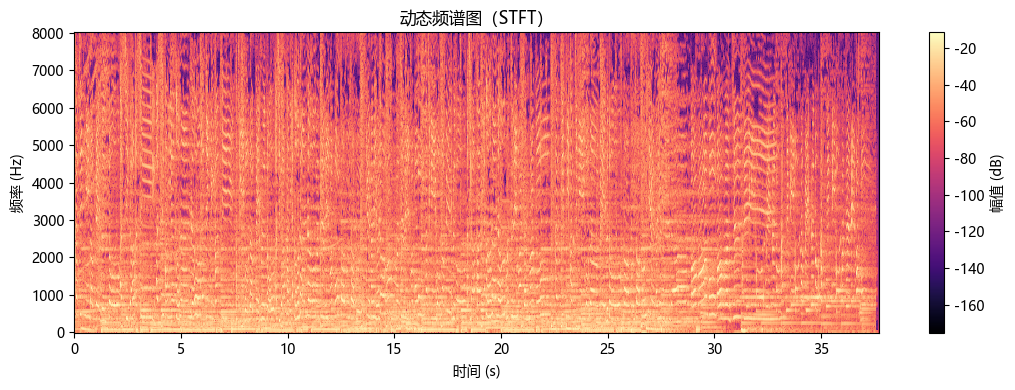

In [ ]:
from scipy.signal import stft

f, t_spec, S = stft(audio, fs=sr, nperseg=512, noverlap=256, window='hann')
S_db = 20 * np.log10(np.abs(S) + 1e-9)

fig, ax = plt.subplots(figsize=(11, 4))
pcm = ax.pcolormesh(t_spec, f, S_db, shading='auto', cmap='magma')
fig.colorbar(pcm, ax=ax, label='幅值 (dB)')
ax.set_title('动态频谱图（STFT）')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('频率 (Hz)')
fig.tight_layout()
fig.savefig('asset/spectrogram.png', dpi=110)
plt.show()